# DefAn: Hallucination Detection via Semantic Entropy & Embedding Geometry

This notebook runs the **full Stage 3–4 pipeline** on the DefAn dataset using
shared utility functions from `hallucination_utils.py`.

**Pipeline overview:**
1. Load and inspect the raw response-level data
2. Response-level EDA (label breakdown by domain and answer type)
3. Embed all responses with SentenceTransformer
4. Extract 5 geometric features per question
5. Question-level EDA (label profiles, naive vs strict rates)
6. Geometric feature exploration (distributions, correlations, pairplot)
7. Statistical tests (KS tests, permutation test)
8. Classification and ablation
9. Feature importance and SHAP
10. UMAP visualisation (optional)


##  Setup

In [1]:
# Uncomment to install dependencies:
# !pip install -q sentence-transformers scikit-learn xgboost scipy shap matplotlib seaborn umap-learn

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Make sure hallucination_utils.py is importable
# (adjust the path if your utils file is in a different directory)
sys.path.insert(0, '.')

from hallucination_utils import *

print('All imports loaded.')
%load_ext autoreload
%autoreload 2

All imports loaded.


## Configuration

In [2]:
# ── Paths ──
DATA_PATH = './data/defan_t0.9_n20.jsonl'
OUTPUT_DIR = 'defan_output'
EMBED_CACHE = 'defan_embeddings.npy'

# ── Feature extraction ──
SIM_THRESHOLD = 0.85

# ── Statistical tests ──
N_PERMUTATIONS = 10000
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

# ── Per-domain ML threshold ──
MIN_QUESTIONS_FOR_ANALYSIS = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)


## Load Data

`load_dataset()` handles DefAn's quirk of not having a `prompt_id` column
(it derives one from the `id` field) and adds `answer_len`.


In [3]:
df = load_dataset(DATA_PATH)
print_loading_summary(df)


Dataset:          defan
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   2377  (23.8%)
  incorrect   :   7621  (76.2%)
  refused     :      2  (0.0%)

Domains (7 unique):
  Humanities
  Law, Business, and Miscellaneous
  Medicine & Health
  STEM
  Science & Technology
  Social Sciences
  Sports

Answer types: ['city', 'date', 'name', 'numeric']


In [4]:
# Question-level metadata (domain_mode, domain inconsistency, etc.)
q_meta = compute_question_metadata(df)
print_domain_consistency(q_meta)


Domain inconsistency: 70/500 questions (14.0%)
Max unique domains per question: 3


In [5]:
# Raw questions per domain
raw_domain_counts = questions_per_domain(df)
print('Questions per domain (raw):')
for dom, n in raw_domain_counts.items():
    print(f'  {dom:35s}: {n}')


Questions per domain (raw):
  Humanities                         : 203
  Social Sciences                    : 166
  STEM                               : 140
  Sports                             : 49
  Medicine & Health                  : 16
  Science & Technology               : 2
  Law, Business, and Miscellaneous   : 1


## Response-Level EDA

Every response gets one of three labels from the judge: **correct**,
**incorrect**, or **refused**. We visualise the breakdown by domain and
answer type before aggregating to question level.


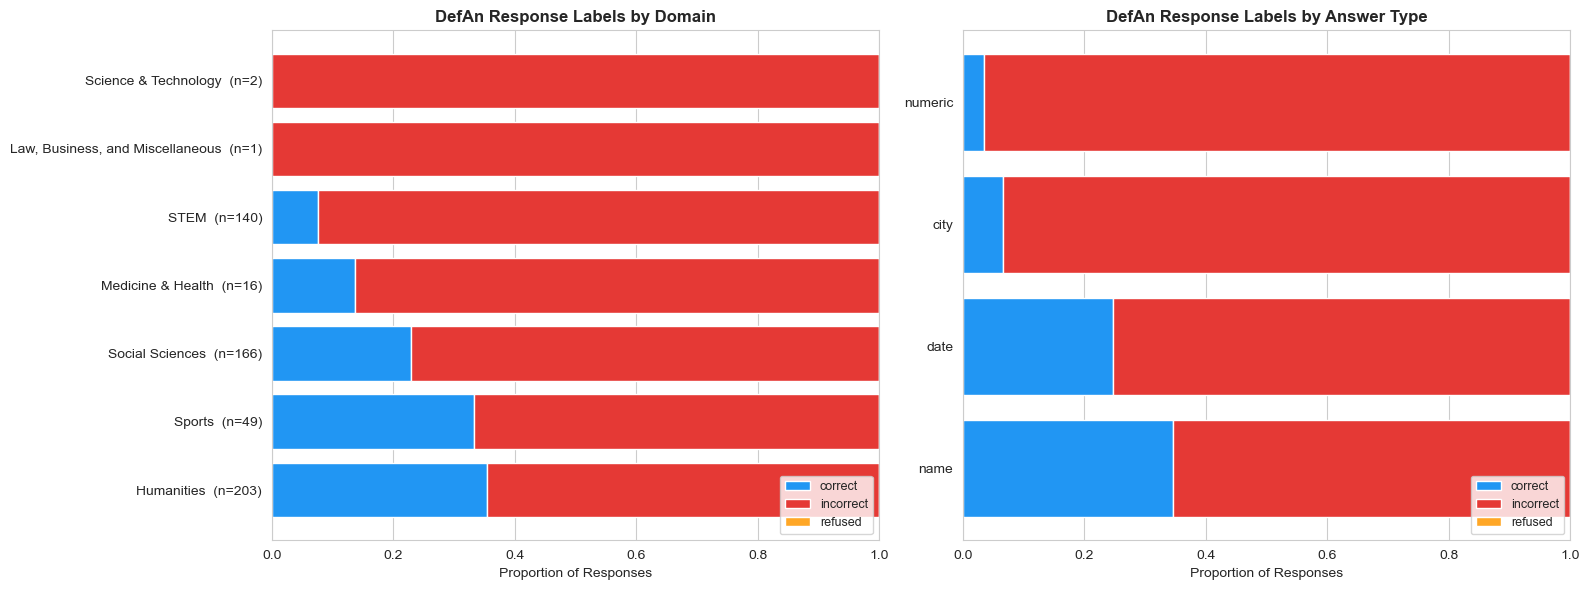

In [6]:
# Stacked bar: domain and answer type (DefAn has real type values)
fig = plot_response_label_breakdown(
    df,
    domain_col='domain',
    domain_question_counts=raw_domain_counts,
    title_prefix='DefAn Response Labels',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_response_label_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()


#### Fig. A stacked bar chart showing the response-level label composition across domains and answer types. It is the first high-level EDA figure and gives a quick sense of how often responses are judged correct, incorrect, or refused before any aggregation to question level.

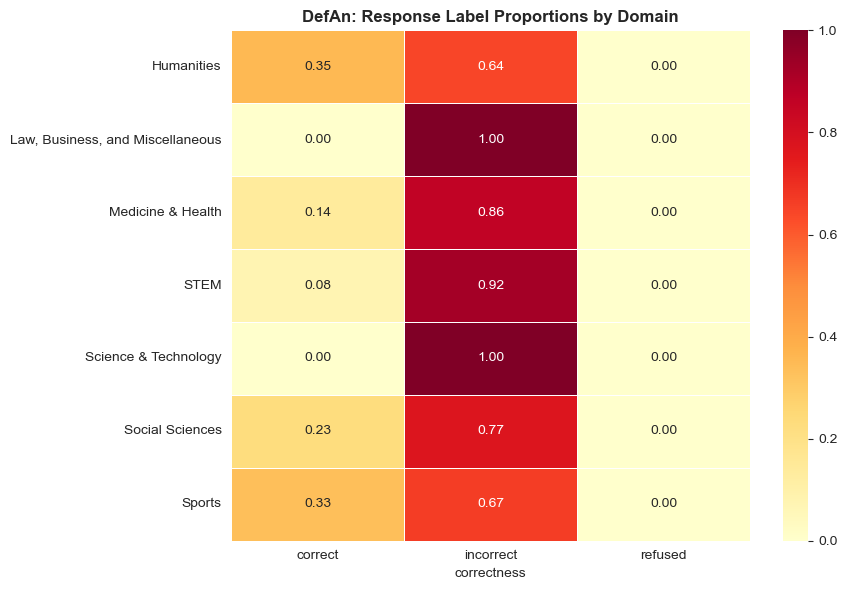

In [7]:
# Heatmap of label proportions by domain
fig = plot_label_proportion_heatmap(
    df,
    domain_col='domain',
    title='DefAn: Response Label Proportions by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_response_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


#### A heatmap of label proportions by domain.

## Embed All Responses

We embed every response regardless of its correctness label. The geometric
features are computed from all 20 embeddings per question — the full response
distribution, including refused outputs, is part of the signal.


In [8]:
all_embeddings = embed_responses(
    df,
    model_name='all-MiniLM-L6-v2',
    cache_path=EMBED_CACHE,
    batch_size=256,
)
print(f'Embedding matrix: {all_embeddings.shape}')


Loading cached embeddings from defan_embeddings.npy
Embedding matrix: (10000, 384)


## Feature Extraction

Per question we extract:
- **5 geometric features** from all 20 response embeddings: semantic entropy,
  cosine dispersion, Mahalanobis distance, cluster count, similarity variance
- **Label fractions** (correct, incorrect, refused) out of 20
- **Strict hallucination rate** = `n_incorrect / (n_correct + n_incorrect)`,
  excluding refused from the denominator
- **Binary label** via majority vote on the strict rate


In [9]:
# Fit the Mahalanobis reference distribution on correct-labeled responses
mu_ref, cov_inv = fit_reference_distribution(all_embeddings, df)


Correct responses for reference: 2377
Reference fitted. mu shape: (384,), precision shape: (384, 384)


In [10]:
# Extract question-level features
feat_df, skipped, skipped_details = extract_question_features(
    df, all_embeddings, mu_ref, cov_inv,
    sim_threshold=SIM_THRESHOLD,
    domain_col='domain',
)

# Save
feat_df.to_csv(os.path.join(OUTPUT_DIR, 'defan_features.csv'), index=False)


  500/500 ...

Questions processed: 500
Questions skipped (all refused): 0
Label distribution:
  Correct (0): 102
  Hallucinated (1): 398
  Rate: 79.6%


### Filtering Diagnostic

In [11]:
analysis_domains, excluded_domains = print_filtering_diagnostic(
    feat_df, raw_domain_counts, skipped, MIN_QUESTIONS_FOR_ANALYSIS,
    domain_col='domain', skipped_details=skipped_details,
)


No questions were skipped.

Surviving questions per domain:
  Humanities                              :  193 /  203  (dropped 10)
  STEM                                    :  137 /  140  (dropped 3)
  Social Sciences                         :  126 /  166  (dropped 40)
  Sports                                  :   28 /   49  (dropped 21)
  Medicine & Health                       :   16 /   16  (dropped 0)

Domains for ML (>= 10 questions): 5


## Question-Level EDA

Each question now has three fractions that sum to ~1. We examine these
label profiles per domain and compare the naive vs strict hallucination rates.


In [12]:
# Summary statistics
frac_cols = ['frac_correct', 'frac_incorrect', 'frac_refused']
print('Per-question label fraction statistics:')
display(feat_df[frac_cols + ['hall_rate_strict', 'hall_rate_naive']].describe().round(3))


Per-question label fraction statistics:


,frac_correct,frac_incorrect,frac_refused,hall_rate_strict,hall_rate_naive
count,500.000,500.000,500.000,500.000,500.000
mean,0.238,0.762,0.000,0.762,0.762
std,0.322,0.321,0.004,0.322,0.322
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.600,0.000,0.600,0.600
50%,0.050,0.950,0.000,0.950,0.950
75%,0.400,1.000,0.000,1.000,1.000
max,1.000,1.000,0.100,1.000,1.000


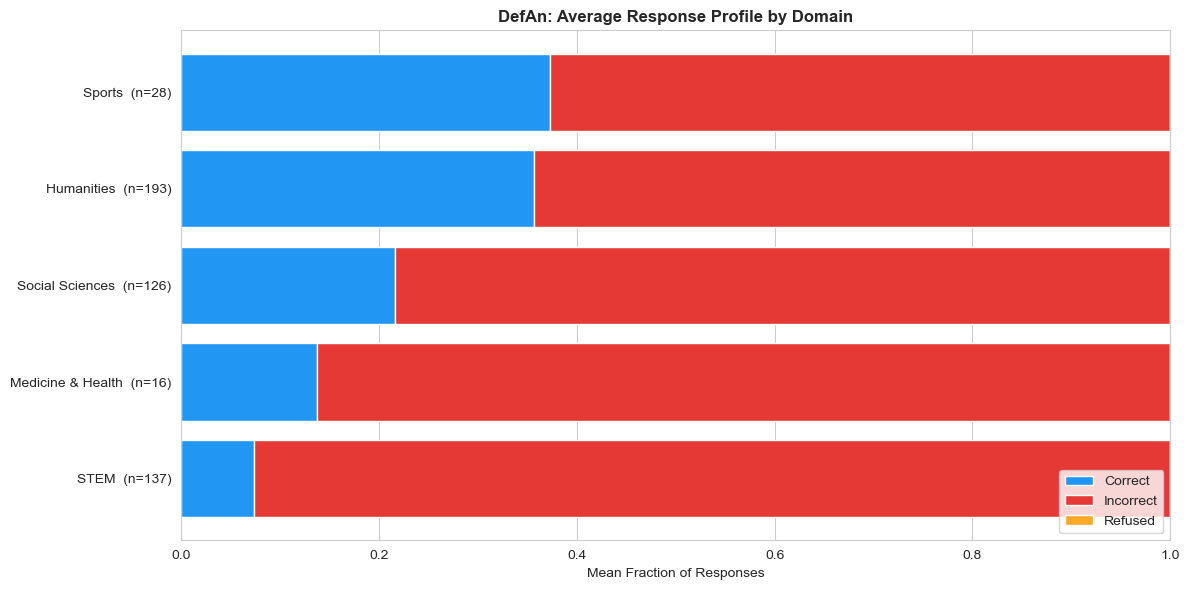

In [13]:
# Stacked bar: mean label fractions by domain
fig = plot_question_label_profiles(
    feat_df,
    frac_cols=['frac_correct', 'frac_incorrect', 'frac_refused'],
    frac_nice_names=['Correct', 'Incorrect', 'Refused'],
    frac_colors=[LABEL_COLORS['correct'], LABEL_COLORS['incorrect'], LABEL_COLORS['refused']],
    domain_col='domain',
    title='DefAn: Average Response Profile by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_question_label_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()


#### A stacked bar plot of the average per-question response profile by domain, using the fractions of correct, incorrect, and refused outputs among the 20 samples per question.


### Domain Summary Table

In [14]:
domain_stats = build_domain_stats(
    feat_df,
    strict_rate_col='hall_rate_strict',
    domain_col='domain',
    extra_mean_cols=['frac_refused'],
    analysis_domains=analysis_domains,
)
display(domain_stats.round(3))
domain_stats.to_csv(os.path.join(OUTPUT_DIR, 'domain_stats.csv'))


,n_questions,n_hallucinated,hall_rate_mean,hall_rate_std,mean_entropy,mean_frac_refused,pct_hallucinated,in_analysis
domain,,,,,,,,
STEM,137,135,0.926,0.131,3.633,0.000,98.5,True
Medicine & Health,16,14,0.862,0.213,3.295,0.000,87.5,True
Social Sciences,126,105,0.784,0.267,1.976,0.000,83.3,True
Humanities,193,127,0.643,0.380,2.276,0.001,65.8,True
Sports,28,17,0.627,0.420,2.623,0.000,60.7,True


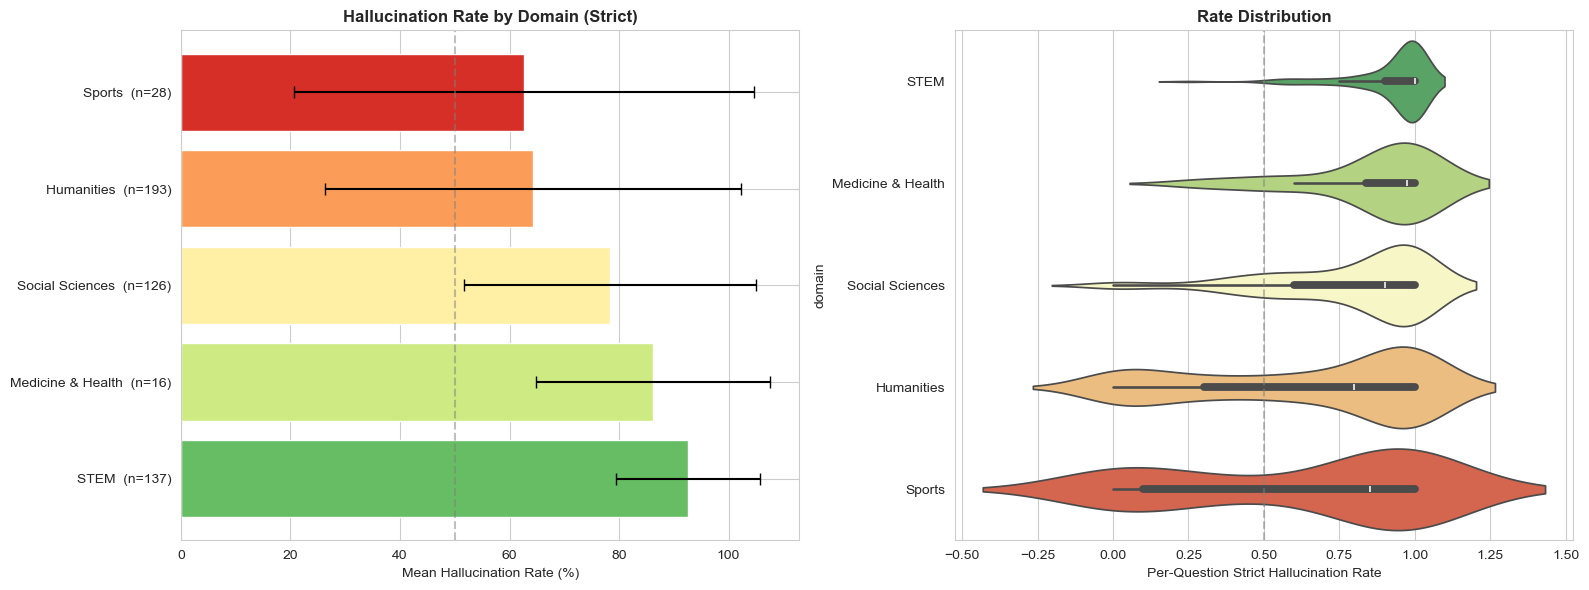

In [15]:
# Bar + violin of hallucination rate by domain
fig = plot_hallucination_rate_by_domain(
    feat_df, domain_stats,
    strict_rate_col='hall_rate_strict',
    domain_col='domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig07_hallu_rate_by_domain.png'), dpi=150, bbox_inches='tight')
plt.show()


#### A bar/violin-style visualization of the strict hallucination rate by domain. This figure is useful because it shows not only the mean rate but also the spread within each domain.

## Geometric Feature Distributions

The 5 embedding-geometry features, split by the binary target label.


In [16]:
for lab, tag in [(0, 'Correct'), (1, 'Hallucinated')]:
    sub = feat_df[feat_df['label'] == lab]
    print(f'--- {tag} (n={len(sub)}) ---')
    display(sub[GEO_FEATURES].describe().round(4))


--- Correct (n=102) ---


,H_sem,D_cos,M_bar,K,sig2_S
count,102.0000,102.0000,102.0000,102.0000,102.0000
mean,1.2913,0.1238,16.9710,4.5882,0.0515
std,0.8443,0.0862,6.9947,2.7838,0.0394
min,-0.0000,0.0031,7.0415,1.0000,0.0001
25%,0.5792,0.0554,12.5266,3.0000,0.0204
50%,1.1394,0.0968,14.9423,4.0000,0.0451
75%,1.7629,0.1713,21.4726,6.0000,0.0692
max,3.5087,0.3603,36.2422,13.0000,0.1790


--- Hallucinated (n=398) ---


,H_sem,D_cos,M_bar,K,sig2_S
count,398.0000,398.0000,398.0000,398.0000,398.0000
mean,2.9660,0.2826,36.8750,11.6080,0.0476
std,1.1004,0.1227,12.4289,5.1582,0.0257
min,-0.0000,0.0190,10.6906,1.0000,0.0007
25%,2.2464,0.1861,28.2248,7.0000,0.0300
50%,3.3394,0.3001,38.8092,12.0000,0.0440
75%,3.8219,0.3793,46.5278,16.0000,0.0591
max,4.3219,0.5132,67.6067,20.0000,0.1740


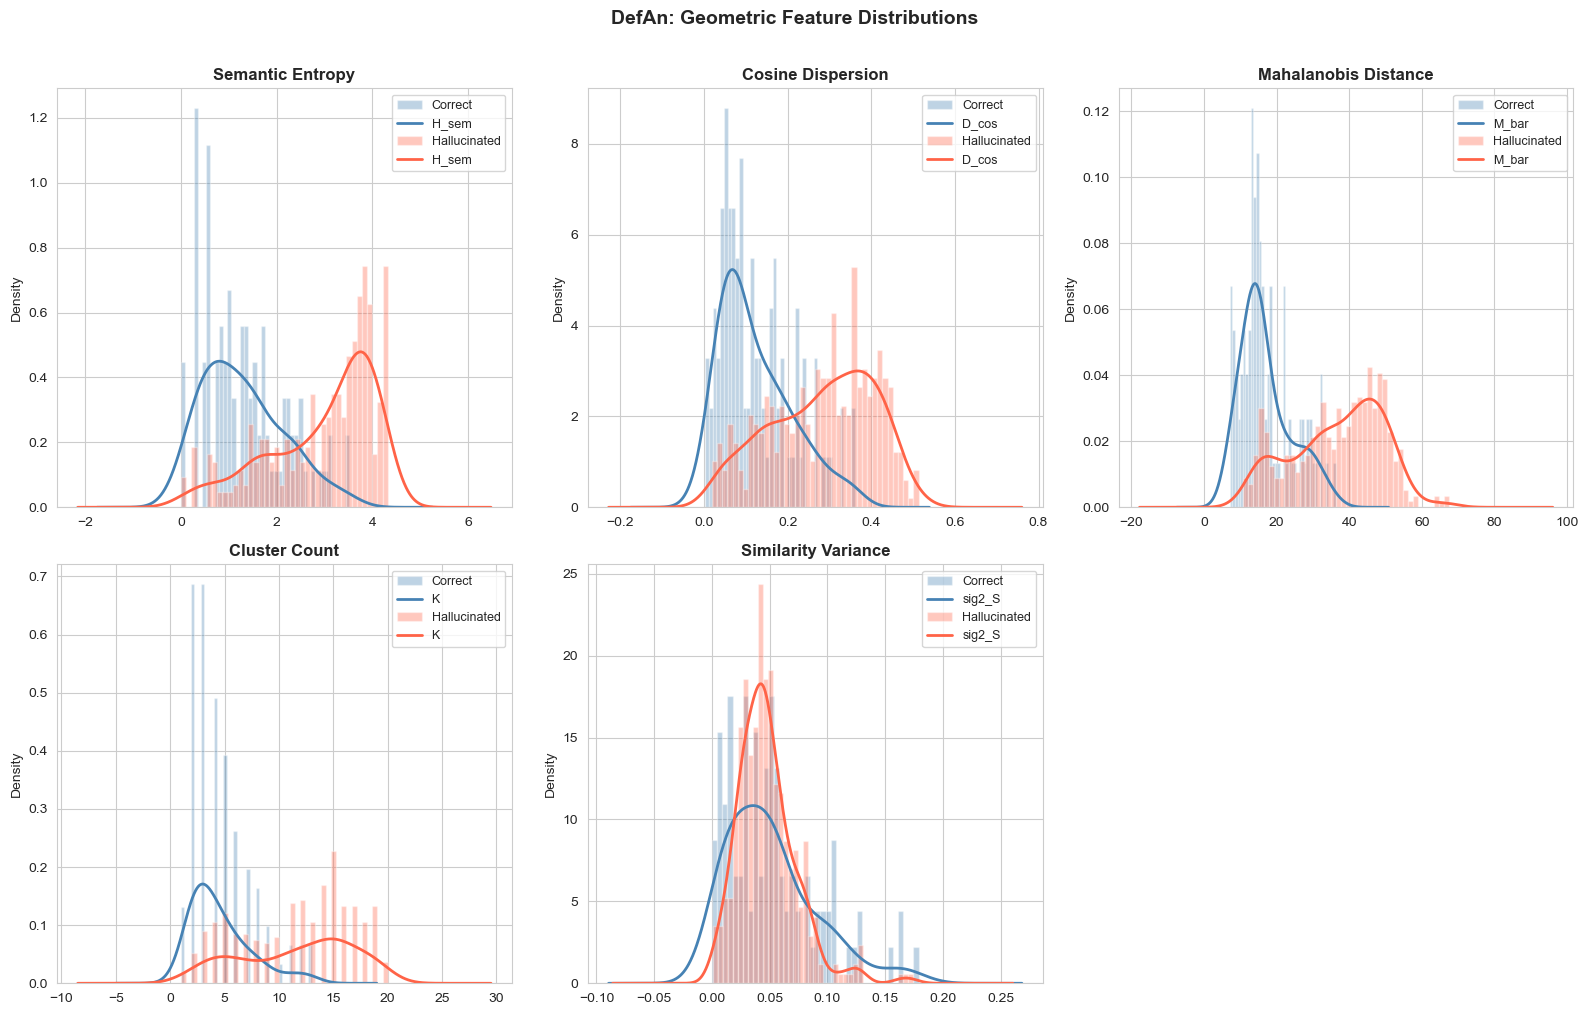

In [17]:
fig = plot_feature_distributions(
    feat_df,
    suptitle='DefAn: Geometric Feature Distributions',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig08_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


#### Distribution plots for the five geometric features: semantic entropy (H_sem), cosine dispersion (D_cos), mean Mahalanobis distance (M_bar), cluster count (K), and similarity variance (sig2_S), split by the binary target label.

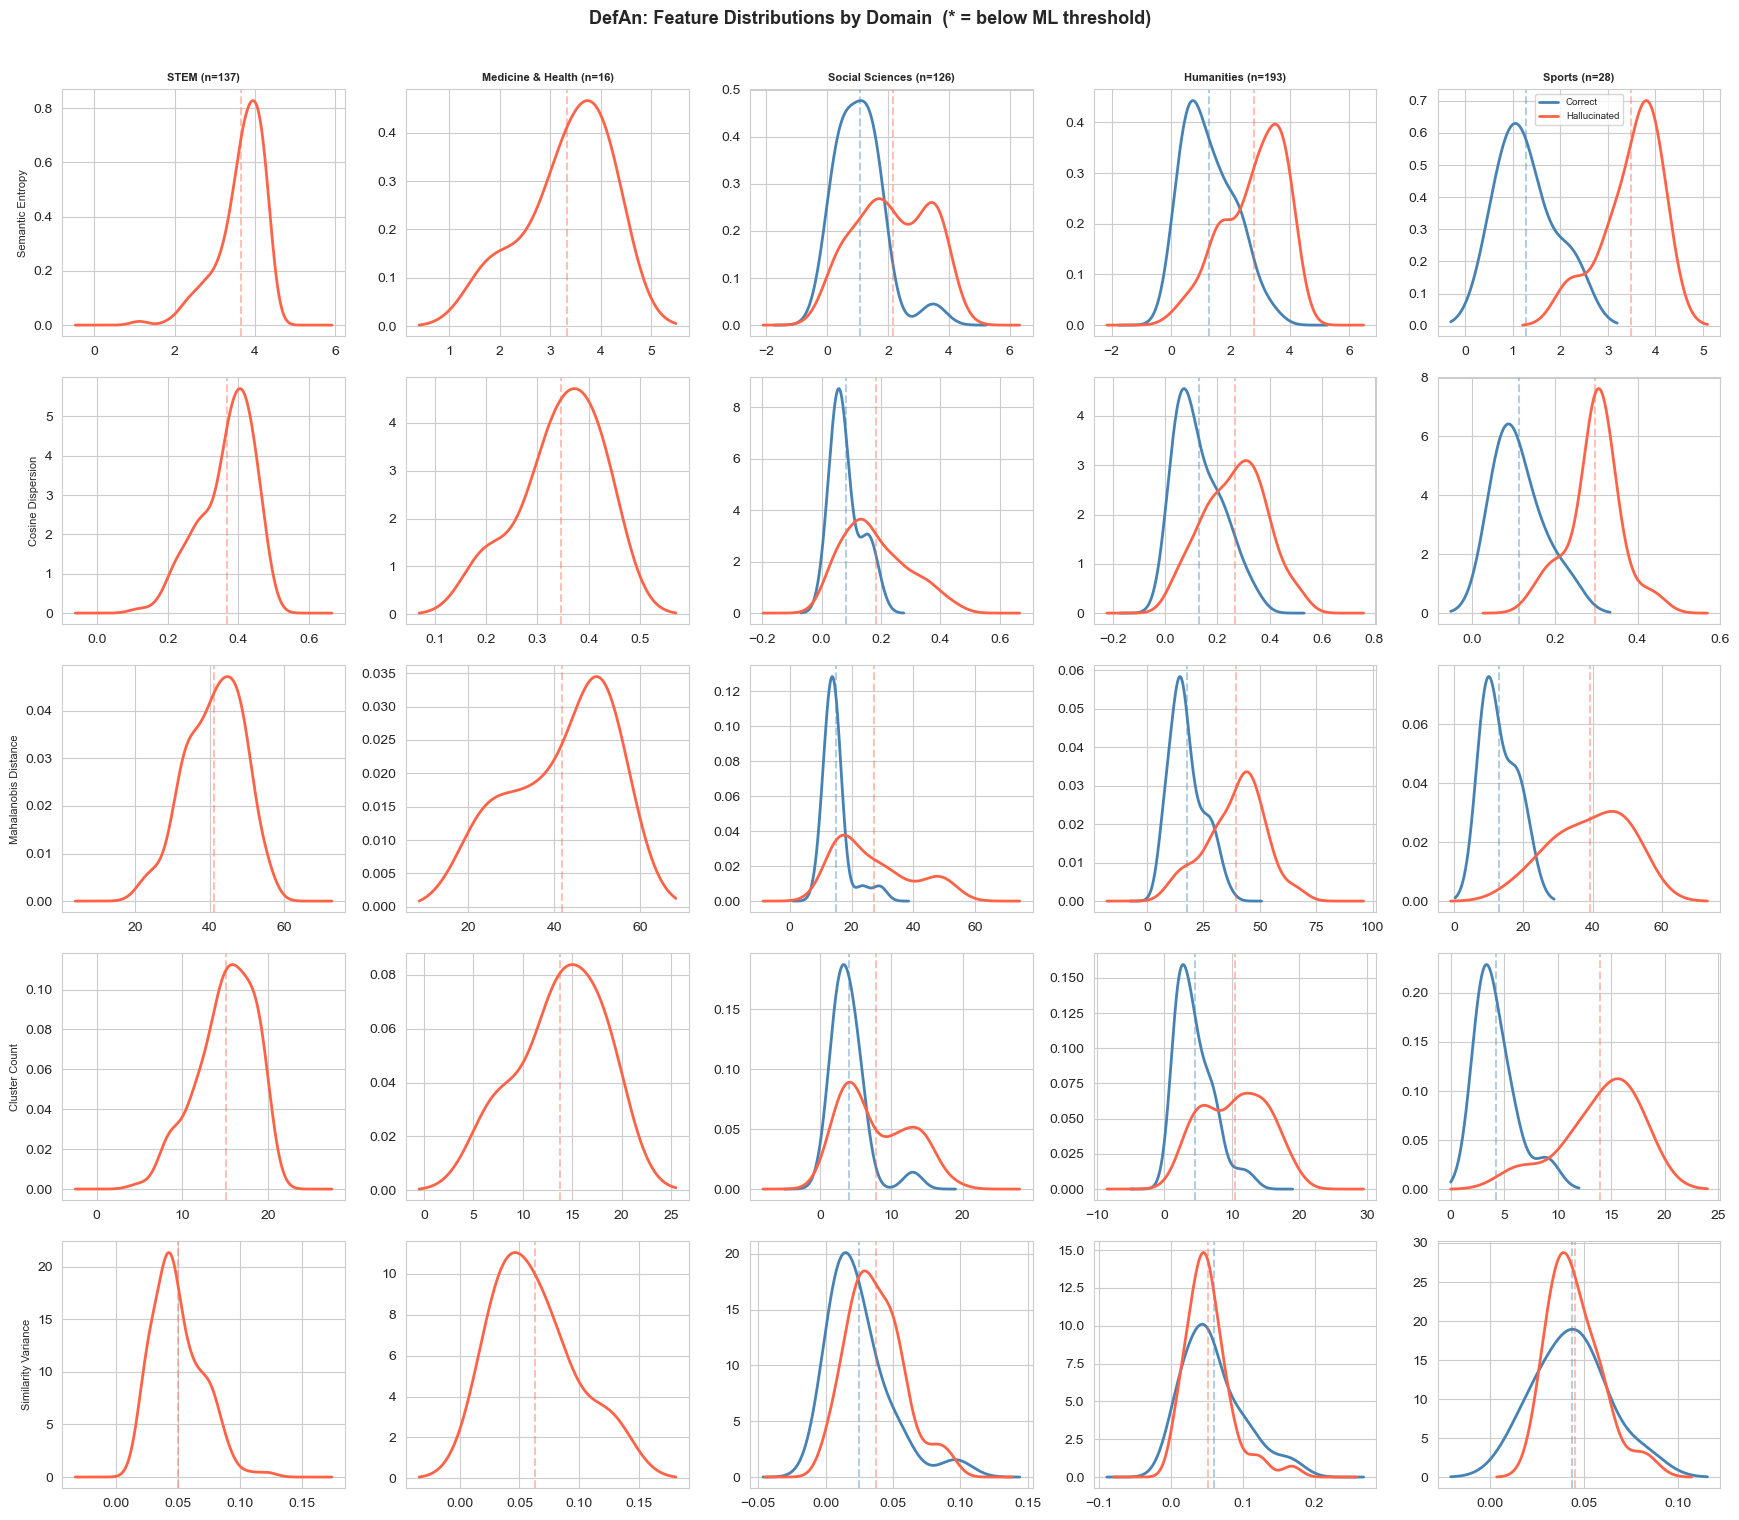

In [18]:
# Per-domain feature KDEs (all domains for EDA)
domains_ordered = domain_stats.reset_index()['domain'].tolist()

fig = plot_per_domain_feature_kdes(
    feat_df,
    domains_ordered=domains_ordered,
    domain_col='domain',
    analysis_domains=analysis_domains,
    suptitle='DefAn: Feature Distributions by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig09_kde_by_domain.png'), dpi=120, bbox_inches='tight')
plt.show()


#### Per-domain KDE panels for the geometric features. This figure asks a more refined question than the global distributions: not just whether features separate the labels overall, but whether they behave similarly across domains.

### Correlation Analysis

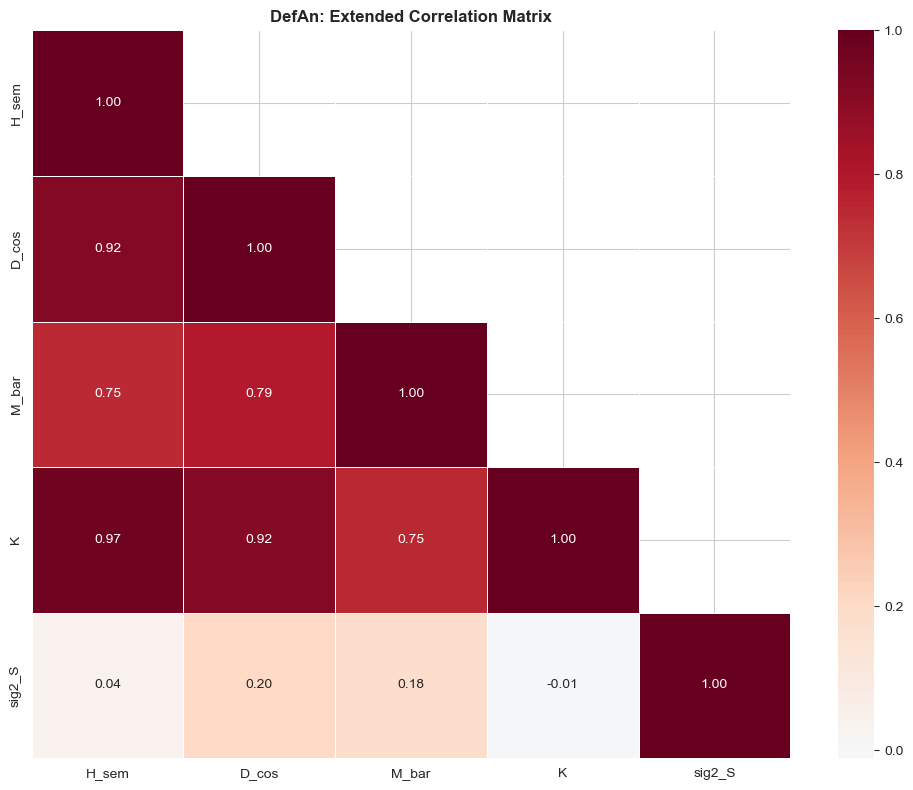

In [19]:
# Geometric features + extra columns
corr_cols = GEO_FEATURES 
fig = plot_correlation_matrix(
    feat_df, cols=corr_cols,
    title='DefAn: Extended Correlation Matrix',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()


#### A correlation heatmap of the geometric features.

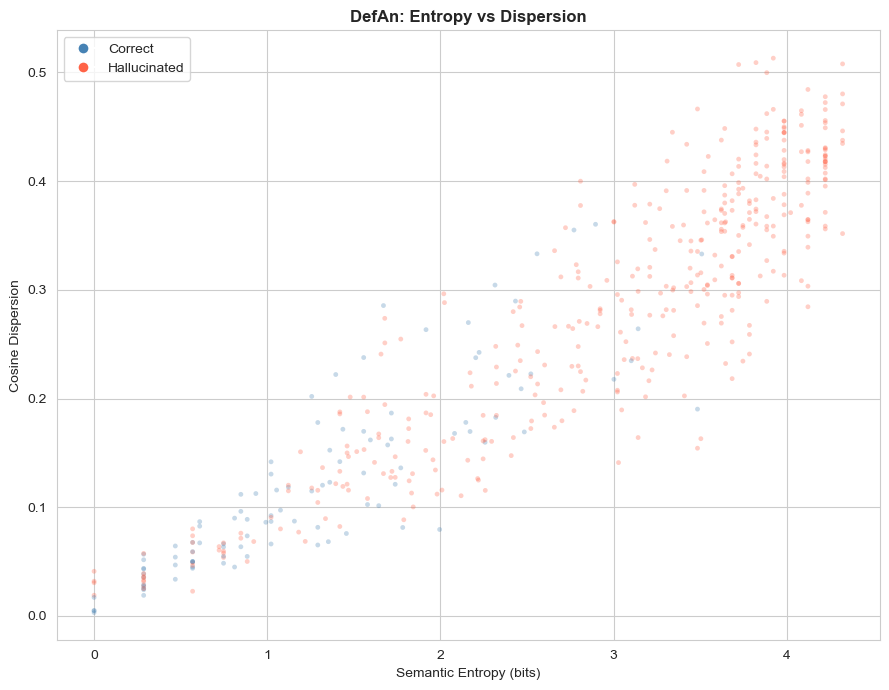

In [20]:
fig = plot_entropy_vs_dispersion(
    feat_df,
    title='DefAn: Entropy vs Dispersion',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig11_entropy_vs_dispersion.png'), dpi=150, bbox_inches='tight')
plt.show()


#### A scatter plot comparing semantic entropy and cosine dispersion.

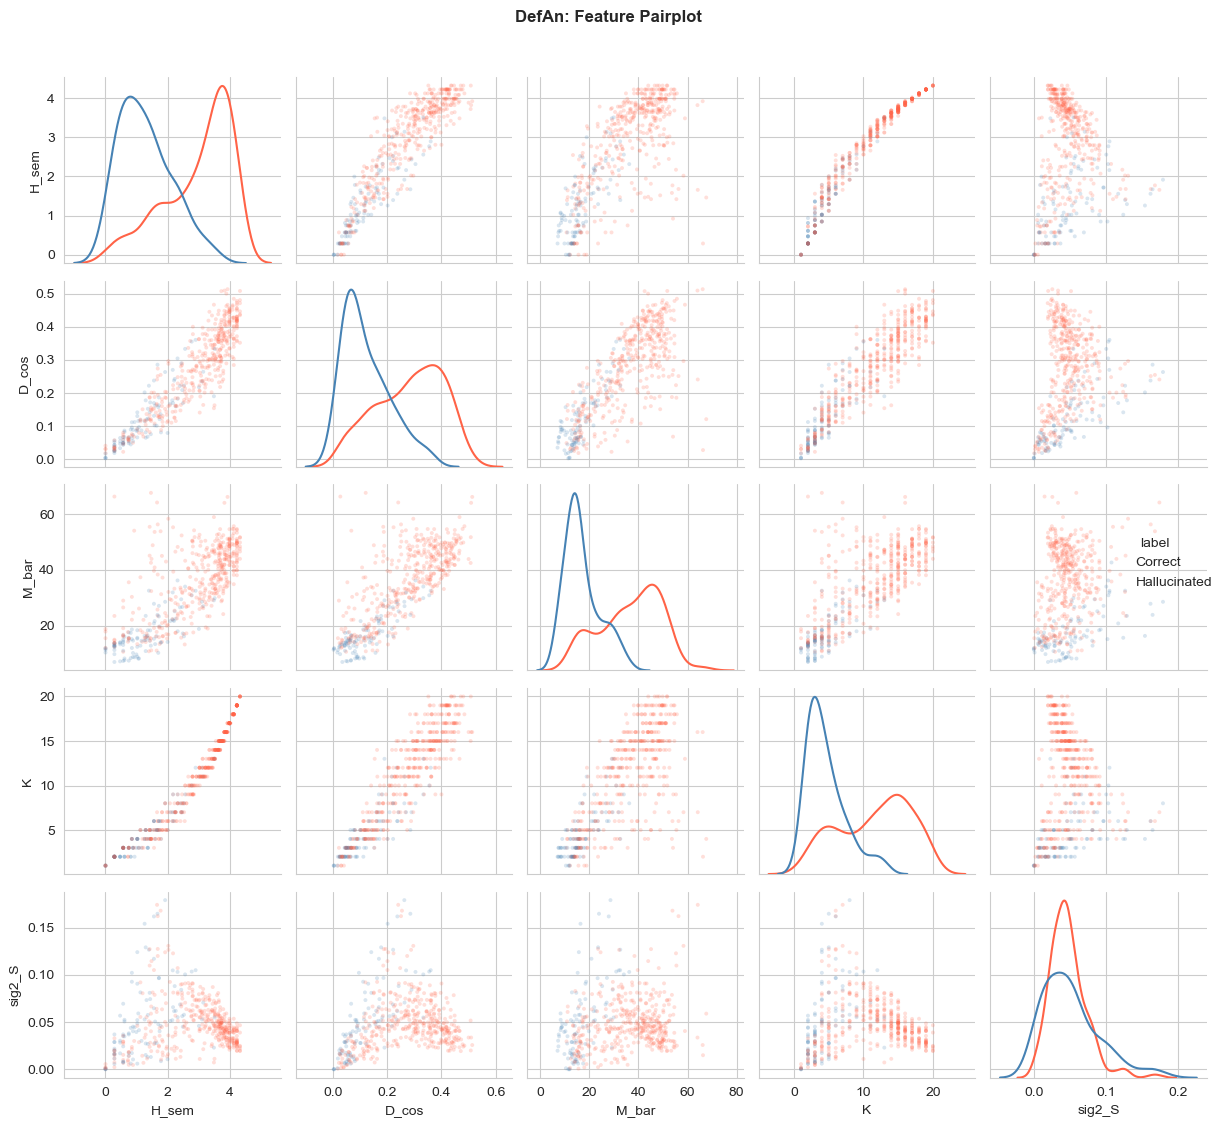

In [21]:
fig = plot_feature_pairplot(
    feat_df,
    suptitle='DefAn: Feature Pairplot',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_pairplot.png'), dpi=100, bbox_inches='tight')
plt.show()


#### A pairplot of the geometric features. This is the most comprehensive exploratory figure for low-dimensional relationships: diagonals show marginal distributions, while off-diagonal panels show pairwise structure.

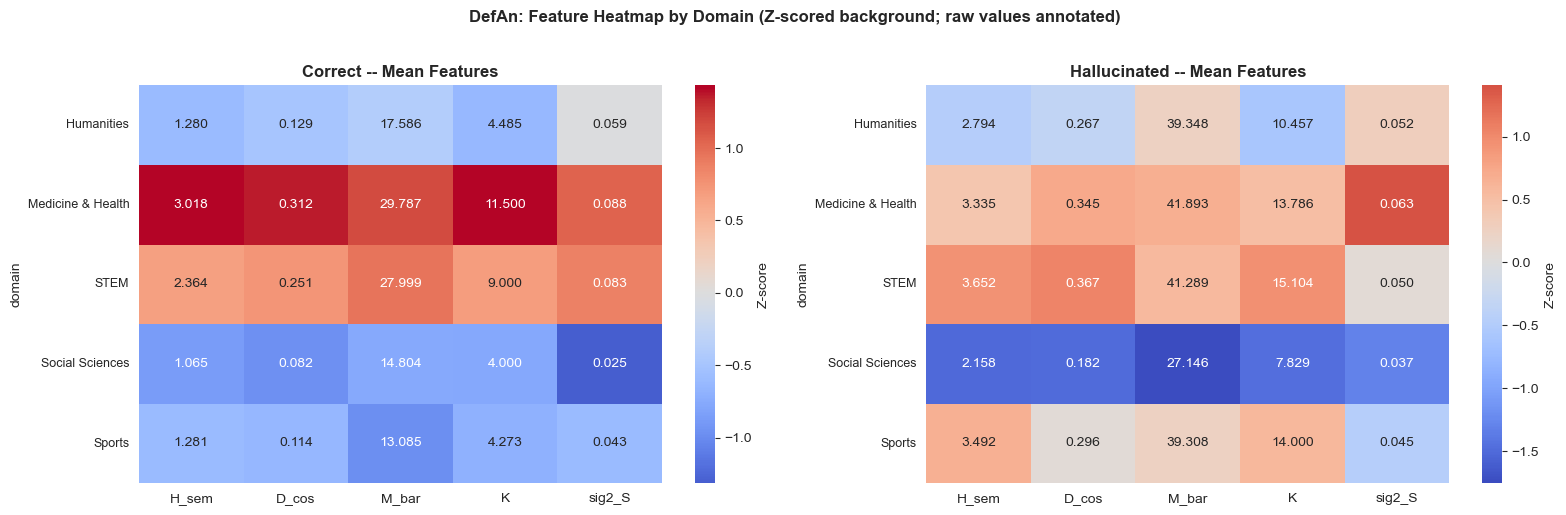

In [22]:
fig = plot_domain_feature_heatmaps(
    feat_df,
    domain_col='domain',
    suptitle='DefAn: Feature Heatmap by Domain',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig13_domain_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()


#### Heatmaps summarizing feature patterns by domain.

## Statistical Tests

### KS Tests — Global and Per-Domain

Two-sample Kolmogorov-Smirnov tests for each geometric feature.


In [23]:
from scipy.stats import ks_2samp

# Global KS tests
print('Global KS tests (Bonferroni alpha = 0.01):')
ks_global = []
for feat in GEO_FEATURES:
    g0 = feat_df.loc[feat_df['label'] == 0, feat].values
    g1 = feat_df.loc[feat_df['label'] == 1, feat].values
    if len(g0) < 2 or len(g1) < 2:
        continue
    stat, p = ks_2samp(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ks_global.append({'Feature': feat, 'KS_stat': stat, 'p_value': p, 'sig': sig})
    print(f'  {feat:10s}  D={stat:.4f}  p={p:.2e}  {sig}')

pd.DataFrame(ks_global).to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_global.csv'), index=False)


Global KS tests (Bonferroni alpha = 0.01):
  H_sem       D=0.6274  p=7.75e-31  ***
  D_cos       D=0.5487  p=3.62e-23  ***
  M_bar       D=0.6603  p=1.86e-34  ***
  K           D=0.6005  p=4.78e-28  ***
  sig2_S      D=0.1624  p=2.40e-02  *


In [24]:
# Per-domain KS tests
all_domains = sorted(feat_df['domain'].unique())
n_tests = len(GEO_FEATURES) * len(all_domains)
alpha_bonf = 0.05 / n_tests
print(f'Tests: {n_tests}, Bonferroni alpha: {alpha_bonf:.6f}')

ks_rows = []
for dom in all_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    for feat in GEO_FEATURES:
        g0 = df_d[df_d['label'] == 0][feat].values
        g1 = df_d[df_d['label'] == 1][feat].values
        if len(g0) < 2 or len(g1) < 2:
            continue
        stat, p = ks_2samp(g0, g1)
        ks_rows.append({
            'Domain': dom, 'Feature': feat,
            'KS_stat': round(stat, 4), 'p_value': p,
            'Significant': p < alpha_bonf,
            'n_questions': len(df_d),
        })

df_ks = pd.DataFrame(ks_rows)
df_ks.to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_per_domain.csv'), index=False)
display(df_ks)


Tests: 25, Bonferroni alpha: 0.002000


,Domain,Feature,KS_stat,p_value,Significant,n_questions
0,Humanities,H_sem,0.5929,8.210559e-15,True,193
1,Humanities,D_cos,0.4983,2.254096e-10,True,193
2,Humanities,M_bar,0.7347,2.387514e-23,True,193
3,Humanities,K,0.5772,5.158691e-14,True,193
4,Humanities,sig2_S,0.1479,2.636262e-01,False,193
5,Medicine & Health,H_sem,0.6429,3.500000e-01,False,16
6,Medicine & Health,D_cos,0.5000,7.000000e-01,False,16
7,Medicine & Health,M_bar,0.7857,1.666667e-01,False,16
8,Medicine & Health,K,0.7143,2.500000e-01,False,16
9,Medicine & Health,sig2_S,0.6429,3.500000e-01,False,16


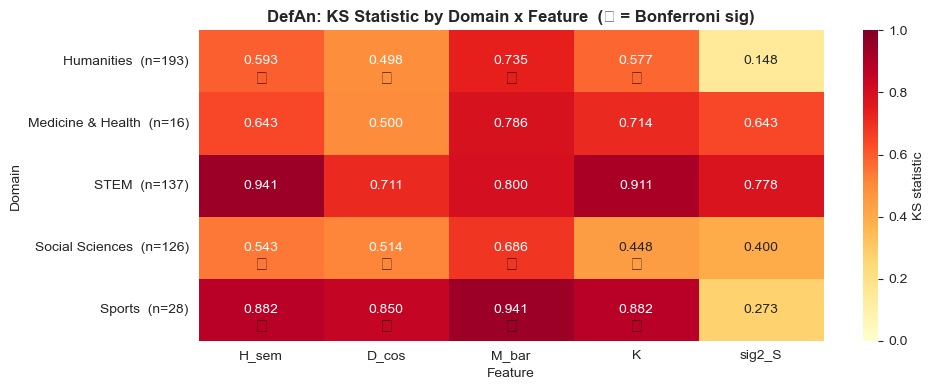

In [25]:
# KS heatmap
survived_counts = feat_df['domain'].value_counts()

fig = plot_ks_heatmap(
    df_ks,
    survived_counts=survived_counts,
    title='DefAn: KS Statistic by Domain x Feature',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig14_ks_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


#### A heatmap of KS statistics for each domain × feature combination. This figure summarizes the per-domain two-sample Kolmogorov-Smirnov tests and is especially useful for seeing where class separation is strongest.

### Permutation Test on Entropy Difference

Observed delta (hallu - correct): 1.6747 bits
Permutation p-value (10000 iters): 0.000000


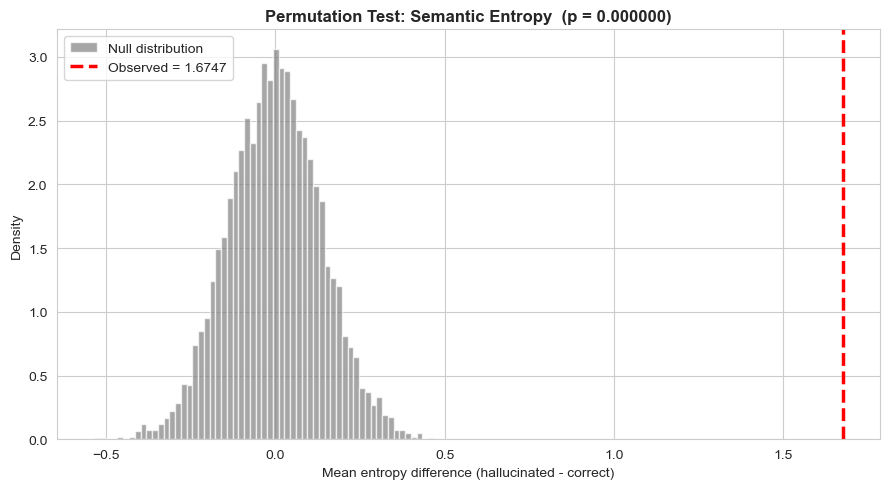

In [26]:
ent_correct = feat_df.loc[feat_df['label'] == 0, 'H_sem'].values
ent_hallu   = feat_df.loc[feat_df['label'] == 1, 'H_sem'].values
delta_obs   = ent_hallu.mean() - ent_correct.mean()
print(f'Observed delta (hallu - correct): {delta_obs:.4f} bits')

all_ent    = feat_df['H_sem'].values
all_labels = feat_df['label'].values
rng = np.random.default_rng(RANDOM_SEED)

perm_deltas = np.zeros(N_PERMUTATIONS)
for p in range(N_PERMUTATIONS):
    shuffled = rng.permutation(all_labels)
    perm_deltas[p] = all_ent[shuffled == 1].mean() - all_ent[shuffled == 0].mean()

perm_pval = (perm_deltas >= delta_obs).sum() / N_PERMUTATIONS
print(f'Permutation p-value ({N_PERMUTATIONS} iters): {perm_pval:.6f}')

fig = plot_permutation_test(perm_deltas, delta_obs, N_PERMUTATIONS, perm_pval)
plt.savefig(os.path.join(OUTPUT_DIR, 'fig15_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


#### A permutation null distribution for the difference in mean semantic entropy between hallucinated and correct questions, with the observed value marked. This is the notebook’s clearest “statistical evidence” figure: it shows that the observed entropy gap is far out in the tail of the null distribution, supporting the claim that entropy is genuinely associated with hallucination rather than reflecting random fluctuation.

## Classification and Ablation

We test feature subsets × classifiers using 5-fold stratified CV.


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from collections import Counter
import xgboost as xgb

EXTENDED_FEATURES = GEO_FEATURES 

X_geo = feat_df[GEO_FEATURES].values
X_ext = feat_df[EXTENDED_FEATURES].values
y_all = feat_df['label'].values

scaler_geo = StandardScaler()
scaler_ext = StandardScaler()
X_geo_sc = scaler_geo.fit_transform(X_geo)
X_ext_sc = scaler_ext.fit_transform(X_ext)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
    ),
}

ablation_sets = {
    'Entropy only (H_sem)':        ('geo', [0]),
    'Geometry only (D_cos, M_bar)': ('geo', [1, 2]),
    'Entropy + Geometry':           ('geo', [0, 1, 2]),
    'All 5 geometric':              ('geo', [0, 1, 2, 3, 4]),
    'All 5 + refused':              ('ext', list(range(len(EXTENDED_FEATURES)))),
}

clf_rows = []
for variant, (fset, feat_idx) in ablation_sets.items():
    X_use = X_geo_sc if fset == 'geo' else X_ext_sc
    X_sub = X_use[:, feat_idx]
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_sub, y_all, cv=cv, scoring='roc_auc')
        clf_rows.append({
            'Variant': variant, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
        })
        print(f'  {variant:35s} | {clf_name:22s} | AUC = {scores.mean():.4f} +/- {scores.std():.4f}')

df_clf = pd.DataFrame(clf_rows)
df_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_results.csv'), index=False)
print()
display(df_clf.pivot_table(index='Variant', columns='Classifier', values='AUC_mean').round(3))


  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.8731 +/- 0.0342
  Entropy only (H_sem)                | Random Forest          | AUC = 0.8428 +/- 0.0213
  Entropy only (H_sem)                | XGBoost                | AUC = 0.8399 +/- 0.0199
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.9039 +/- 0.0290
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.8845 +/- 0.0288
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.8739 +/- 0.0277
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.9114 +/- 0.0335
  Entropy + Geometry                  | Random Forest          | AUC = 0.9013 +/- 0.0197
  Entropy + Geometry                  | XGBoost                | AUC = 0.9048 +/- 0.0132
  All 5 geometric                     | Logistic Regression    | AUC = 0.9239 +/- 0.0170
  All 5 geometric                     | Random Forest          | AUC = 0.9162 +/- 0.0223
  All 5 geometric    

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 + refused,0.924,0.916,0.912
All 5 geometric,0.924,0.916,0.912
Entropy + Geometry,0.911,0.901,0.905
Entropy only (H_sem),0.873,0.843,0.840
"Geometry only (D_cos, M_bar)",0.904,0.885,0.874


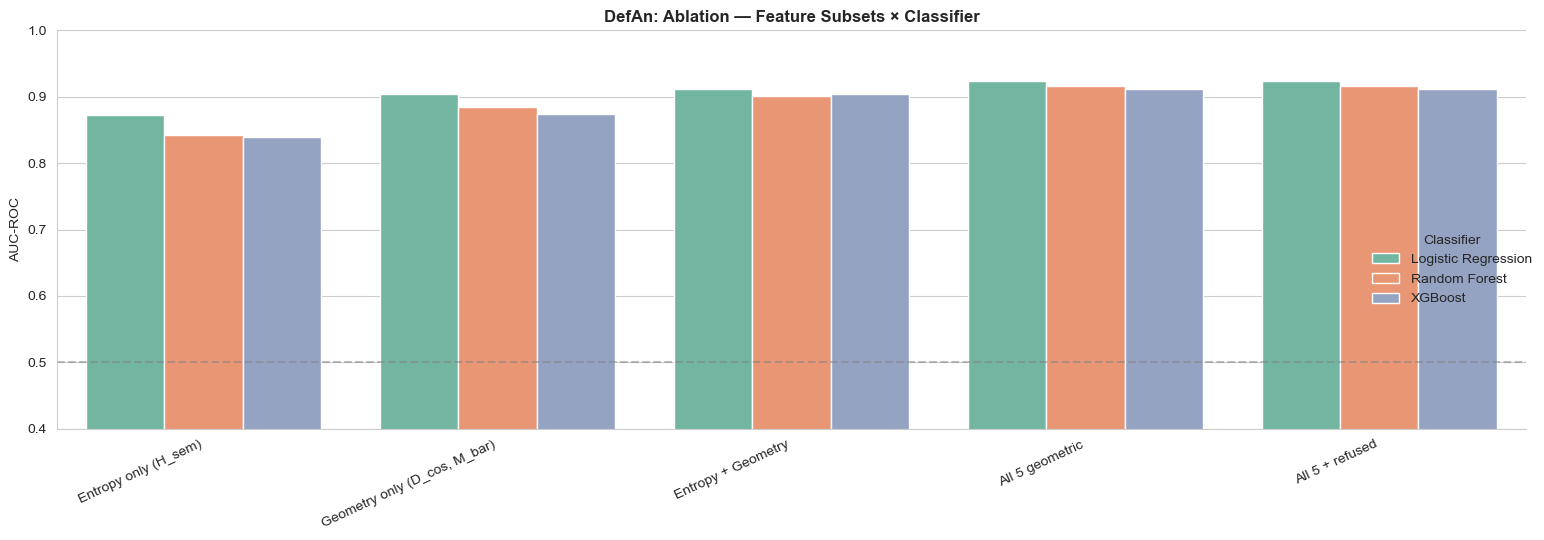

In [28]:
# Ablation bar chart
import seaborn as sns

g = sns.catplot(
    data=df_clf, kind='bar',
    x='Variant', y='AUC_mean', hue='Classifier',
    palette='Set2', height=5.5, aspect=2.5,
    capsize=0.05, errwidth=1.5,
)
g.ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
g.ax.set_ylim(0.4, 1.0)
g.ax.set_title('DefAn: Ablation — Feature Subsets × Classifier', fontweight='bold')
g.ax.set_ylabel('AUC-ROC')
g.ax.set_xlabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig16_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()


#### A grouped bar chart comparing AUC-ROC across feature subsets and classifiers. This figure tells the model-selection story

### Per-Domain Classification

In [29]:
domain_clf_rows = []

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    X_d = df_d[GEO_FEATURES].values
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'  Skipping {dom} (single class)')
        continue
    X_d_sc = StandardScaler().fit_transform(X_d)
    for clf_name, clf in classifiers.items():
        n_folds = min(5, min(Counter(y_d).values()))
        if n_folds < 2:
            continue
        cv_d = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
        scores = cross_val_score(clf, X_d_sc, y_d, cv=cv_d, scoring='roc_auc')
        domain_clf_rows.append({
            'Domain': dom, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
            'n_questions': len(df_d),
        })

if excluded_domains:
    print(f'Excluded from per-domain classification (< {MIN_QUESTIONS_FOR_ANALYSIS} questions): {excluded_domains}')

df_dom_clf = pd.DataFrame(domain_clf_rows)
df_dom_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_per_domain.csv'), index=False)
display(df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean').round(3))


Classifier,Logistic Regression,Random Forest,XGBoost
Domain,,,
Humanities,0.943,0.922,0.930
Medicine & Health,0.571,0.714,0.500
STEM,0.866,0.706,0.822
Social Sciences,0.822,0.823,0.772
Sports,1.000,1.000,0.975


### Bootstrap AUC Confidence Intervals

In [30]:
rng_boot = np.random.default_rng(RANDOM_SEED)

# Global bootstrap
print('Global bootstrap (RF, 5 geometric features):')
auc_boot_global = []
for _ in range(N_BOOTSTRAP):
    idx = rng_boot.choice(len(y_all), len(y_all), replace=True)
    oob = np.setdiff1d(np.arange(len(y_all)), idx)
    if len(oob) < 10 or len(np.unique(y_all[oob])) < 2:
        continue
    if len(np.unique(y_all[idx])) < 2:
        continue
    rf_b = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=0)
    rf_b.fit(X_geo_sc[idx], y_all[idx])
    proba = rf_b.predict_proba(X_geo_sc[oob])[:, 1]
    auc_boot_global.append(roc_auc_score(y_all[oob], proba))

auc_boot_global = np.array(auc_boot_global)
ci_lo, ci_hi = np.percentile(auc_boot_global, [2.5, 97.5])
print(f'  AUC = {auc_boot_global.mean():.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')


Global bootstrap (RF, 5 geometric features):
  AUC = 0.9123  95% CI [0.8705, 0.9457]


In [31]:
# Per-domain bootstrap (analysis_domains only)
boot_rows = []
print('Per-domain bootstrap:')
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        continue
    auc_list = []
    for _ in range(N_BOOTSTRAP):
        idx = rng_boot.choice(len(y_d), len(y_d), replace=True)
        oob = np.setdiff1d(np.arange(len(y_d)), idx)
        if len(oob) < 5 or len(np.unique(y_d[oob])) < 2:
            continue
        if len(np.unique(y_d[idx])) < 2:
            continue
        rf_b = RandomForestClassifier(n_estimators=50, random_state=0)
        rf_b.fit(X_d[idx], y_d[idx])
        proba = rf_b.predict_proba(X_d[oob])[:, 1]
        auc_list.append(roc_auc_score(y_d[oob], proba))
    if len(auc_list) < 10:
        continue
    arr = np.array(auc_list)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    boot_rows.append({
        'Domain': dom, 'AUC_mean': arr.mean(),
        'CI_low': lo, 'CI_high': hi, 'n_questions': len(df_d),
    })
    print(f'  {dom:30s}  AUC={arr.mean():.3f}  [{lo:.3f}, {hi:.3f}]  (n={len(df_d)})')

if excluded_domains:
    print(f'\nExcluded: {excluded_domains}')

df_boot = pd.DataFrame(boot_rows).sort_values('AUC_mean', ascending=True)
df_boot.to_csv(os.path.join(OUTPUT_DIR, 'bootstrap_auc.csv'), index=False)


Per-domain bootstrap:
  Humanities                      AUC=0.931  [0.871, 0.974]  (n=193)
  Medicine & Health               AUC=0.677  [0.250, 1.000]  (n=16)
  STEM                            AUC=0.614  [0.430, 0.978]  (n=137)
  Social Sciences                 AUC=0.805  [0.644, 0.943]  (n=126)
  Sports                          AUC=0.973  [0.875, 1.000]  (n=28)


### ROC Curves

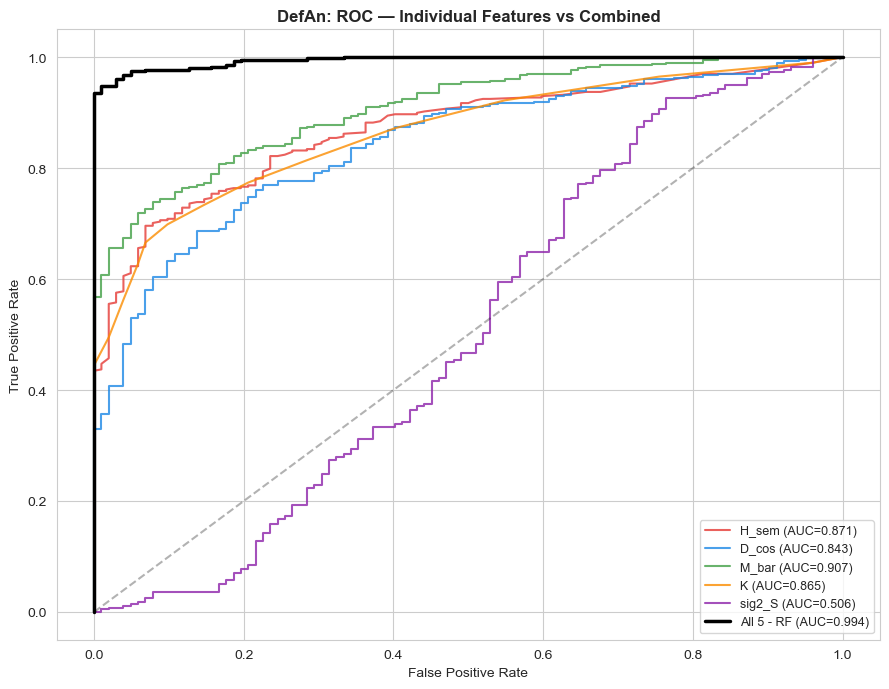

In [32]:
# Individual features vs combined
fig, ax = plt.subplots(figsize=(9, 7))
feat_colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

for i, (feat, color) in enumerate(zip(GEO_FEATURES, feat_colors)):
    vals = X_geo_sc[:, i]
    fpr, tpr, _ = roc_curve(y_all, vals)
    auc_s = roc_auc_score(y_all, vals)
    ax.plot(fpr, tpr, color=color, linewidth=1.5, alpha=0.8,
            label=f'{feat} (AUC={auc_s:.3f})')

# Combined RF
rf_full = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)
rf_full.fit(X_geo_sc, y_all)
y_scores = rf_full.predict_proba(X_geo_sc)[:, 1]
fpr_a, tpr_a, _ = roc_curve(y_all, y_scores)
auc_a = roc_auc_score(y_all, y_scores)
ax.plot(fpr_a, tpr_a, color='black', linewidth=2.5,
        label=f'All 5 - RF (AUC={auc_a:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('DefAn: ROC — Individual Features vs Combined', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig17_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


#### ROC curves comparing each individual feature against the combined random-forest model. This figure is useful because it shows the gap between single-feature performance and multi-feature performance in a visually intuitive way.

## Feature Importance and SHAP

XGBoost GAIN per domain + SHAP beeswarm plots. Only analysis domains
(≥ threshold questions) are included.


In [33]:
import shap

xgb_imp = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
)

importance_data = {}
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        importance_data[dom] = np.zeros(5)
        continue
    xgb_imp.fit(X_d, y_d)
    booster = xgb_imp.get_booster()
    gain_dict = booster.get_score(importance_type='gain')
    gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(5)], dtype=float)
    total = gains.sum()
    importance_data[dom] = gains / total if total > 0 else gains

df_imp = pd.DataFrame(importance_data, index=GEO_FEATURES).T
print('Normalized GAIN importance per domain:')
display(df_imp.round(3))


Normalized GAIN importance per domain:


,H_sem,D_cos,M_bar,K,sig2_S
Humanities,0.245,0.079,0.407,0.143,0.126
Medicine & Health,0.369,0.045,0.586,0.000,0.000
STEM,0.372,0.037,0.150,0.426,0.015
Social Sciences,0.139,0.170,0.429,0.149,0.113
Sports,0.095,0.633,0.235,0.028,0.008


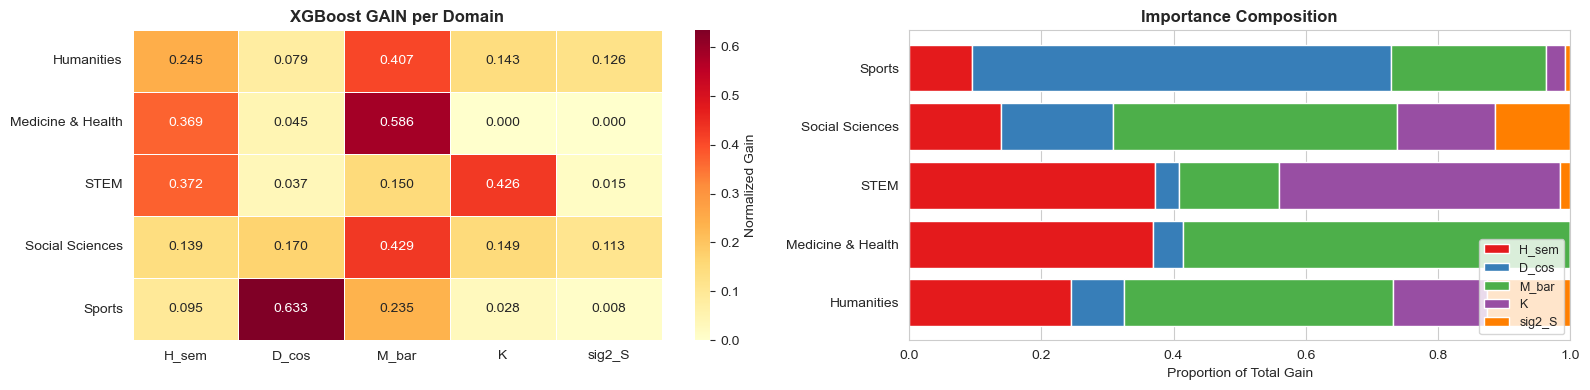

In [34]:
# Importance heatmap + stacked bar
feat_colors_list = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(analysis_domains) * 0.6 + 1)))

sns.heatmap(df_imp, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=df_imp.values.max(),
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Normalized Gain'})
axes[0].set_title('XGBoost GAIN per Domain', fontweight='bold')

bottoms = np.zeros(len(df_imp))
for feat, color in zip(GEO_FEATURES, feat_colors_list):
    vals = df_imp[feat].values
    axes[1].barh(df_imp.index, vals, left=bottoms, color=color, label=feat)
    bottoms += vals
axes[1].set_xlabel('Proportion of Total Gain')
axes[1].set_title('Importance Composition', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig18_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()


#### A two-part feature-importance figure: a heatmap of XGBoost normalized gain by domain and a stacked bar chart showing the composition of total gain.

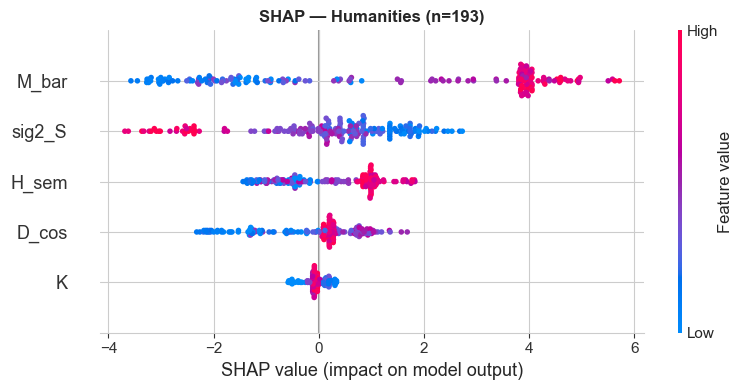

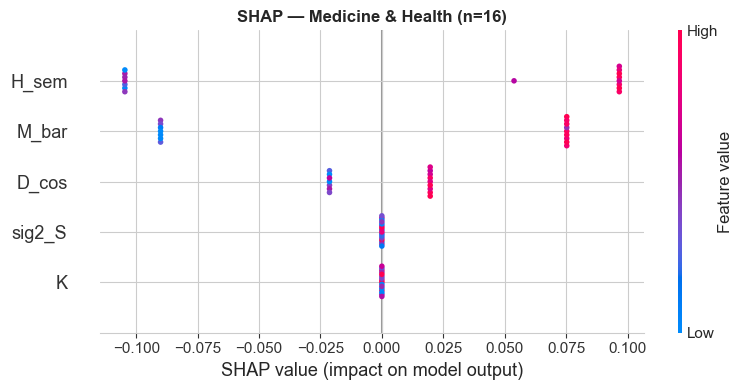

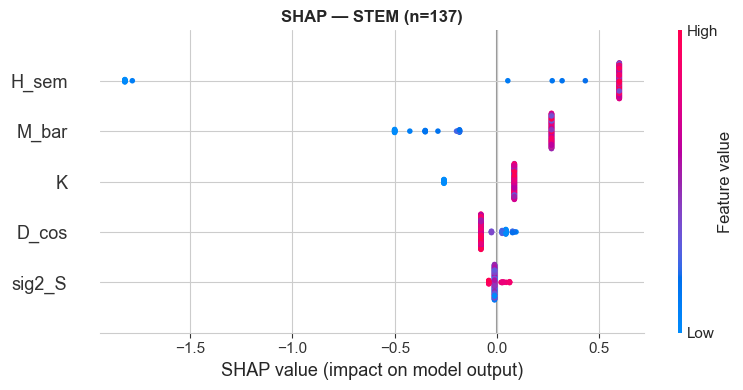

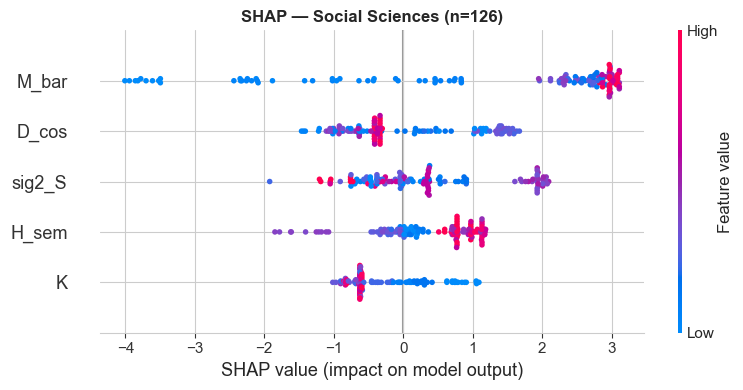

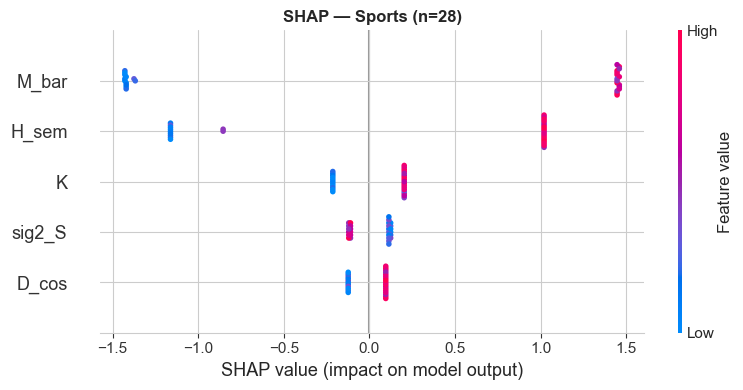

In [35]:
# SHAP beeswarms per domain
xgb_shap = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0,
)

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'Skipping {dom}')
        continue
    xgb_shap.fit(X_d, y_d)
    explainer = shap.TreeExplainer(xgb_shap)
    sv = explainer.shap_values(X_d)
    if isinstance(sv, list):
        sv = sv[1]
    plt.figure(figsize=(8, 4))
    shap.summary_plot(sv, X_d, feature_names=GEO_FEATURES, show=False, plot_size=None)
    plt.title(f'SHAP — {dom} (n={len(df_d)})', fontweight='bold')
    plt.tight_layout()
    plt.show()

if excluded_domains:
    print(f'Excluded from per-domain SHAP: {excluded_domains}')


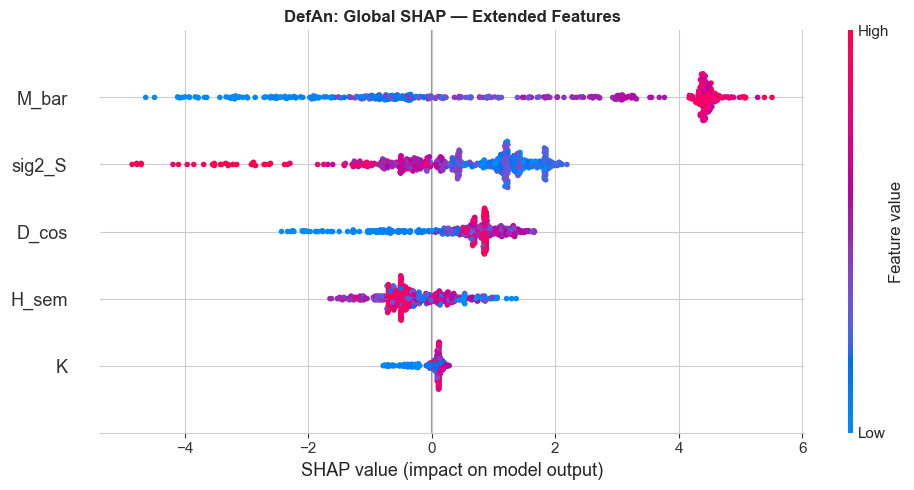

In [36]:
# Global SHAP on extended features
xgb_shap.fit(X_ext_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_global = explainer.shap_values(X_ext_sc)
if isinstance(sv_global, list):
    sv_global = sv_global[1]

plt.figure(figsize=(10, 5))
shap.summary_plot(sv_global, X_ext_sc, feature_names=EXTENDED_FEATURES,
                  show=False, plot_size=None)
plt.title('DefAn: Global SHAP — Extended Features', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig19_shap_global.png'), dpi=150, bbox_inches='tight')
plt.show()


#### These pages contain the domain-specific SHAP summary plots produced in the loop over analysis domains.

## UMAP

UMAP projection of response embeddings, coloured by correctness label.


Running UMAP on 8000 points...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


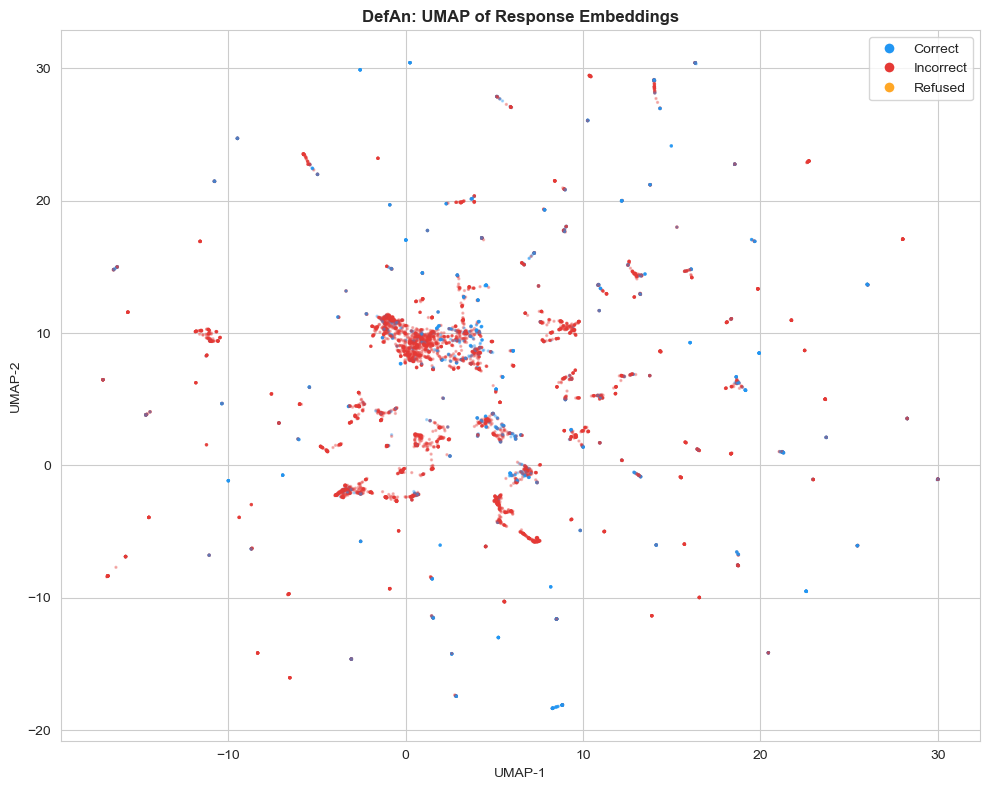

In [37]:
try:
    import umap

    max_pts = 8000
    rng_u = np.random.default_rng(RANDOM_SEED)
    if all_embeddings.shape[0] > max_pts:
        idx_sub = rng_u.choice(all_embeddings.shape[0], max_pts, replace=False)
    else:
        idx_sub = np.arange(all_embeddings.shape[0])

    emb_sub = all_embeddings[idx_sub]
    lab_sub = df['correctness'].values[idx_sub]

    print(f'Running UMAP on {len(idx_sub)} points...')
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
    proj = reducer.fit_transform(emb_sub)

    fig = plot_umap(proj, lab_sub, title='DefAn: UMAP of Response Embeddings')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig20_umap.png'), dpi=120, bbox_inches='tight')
    plt.show()

except ImportError:
    print('umap-learn not installed, skipping UMAP.')


## Summary

In [38]:
print('=' * 70)
print('DEFAN HALLUCINATION DETECTION — RESULTS SUMMARY')
print('=' * 70)
ds_name = df['dataset'].iloc[0]
print(f'  Dataset: {ds_name}')
print(f'  Total questions (raw): {df["prompt_id"].nunique()}')
print(f'  Questions analyzed: {len(feat_df)}')
print(f'  Questions skipped (all refused): {skipped}')
print(f'  Samples per question: 20')
print(f'  All domains: {len(all_domains)}')
print(f'  Domains in ML analyses (>= {MIN_QUESTIONS_FOR_ANALYSIS}): {len(analysis_domains)}')
if excluded_domains:
    print(f'  Excluded from ML: {excluded_domains}')
print()

resp_counts = df['correctness'].value_counts()
print('  Response-level breakdown:')
for lab in LABEL_ORDER:
    if lab in resp_counts.index:
        pct = resp_counts[lab] / len(df) * 100
        print(f'    {lab:12s}: {resp_counts[lab]:6d}  ({pct:.1f}%)')
print()

print(f'  Binary label (strict):')
print(f'    Correct: {(feat_df["label"]==0).sum()}, Hallucinated: {(feat_df["label"]==1).sum()}')
print(f'    Rate: {feat_df["label"].mean()*100:.1f}%')
print()

print(f'  Permutation test (entropy):')
print(f'    delta = {delta_obs:.4f} bits, p = {perm_pval:.6f}')
print()

print(f'  Bootstrap AUC (RF, 5 geometric features):')
print(f'    AUC = {auc_boot_global.mean():.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()

best = df_clf.loc[df_clf['AUC_mean'].idxmax()]
print(f'  Best classifier config:')
print(f'    {best["Classifier"]} / {best["Variant"]} — AUC={best["AUC_mean"]:.4f}')
print()

print(f'  Top feature by domain (XGBoost GAIN):')
for dom, row in df_imp.iterrows():
    top = row.idxmax()
    print(f'    {dom:30s}: {top} ({row[top]:.3f})')
print()
print(f'  Outputs: {OUTPUT_DIR}/')
print('=' * 70)


DEFAN HALLUCINATION DETECTION — RESULTS SUMMARY
  Dataset: defan
  Total questions (raw): 500
  Questions analyzed: 500
  Questions skipped (all refused): 0
  Samples per question: 20
  All domains: 5
  Domains in ML analyses (>= 10): 5

  Response-level breakdown:
    correct     :   2377  (23.8%)
    incorrect   :   7621  (76.2%)
    refused     :      2  (0.0%)

  Binary label (strict):
    Correct: 102, Hallucinated: 398
    Rate: 79.6%

  Permutation test (entropy):
    delta = 1.6747 bits, p = 0.000000

  Bootstrap AUC (RF, 5 geometric features):
    AUC = 0.9123, 95% CI [0.8705, 0.9457]

  Best classifier config:
    Logistic Regression / All 5 geometric — AUC=0.9239

  Top feature by domain (XGBoost GAIN):
    Humanities                    : M_bar (0.407)
    Medicine & Health             : M_bar (0.586)
    STEM                          : K (0.426)
    Social Sciences               : M_bar (0.429)
    Sports                        : D_cos (0.633)

  Outputs: defan_output/
